# Example-07: Estimation of parameters with DHT

In [1]:
# Import

import numpy
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# Estimate reference parameters

# Set window

length = 4096
w = Window(length, 'cosine_window', 5.0, dtype=dtype, device=device)

# Load data

d = Data.from_file(54, w, '../virtual_tbt.npy')

# Estimate frequency

f = Frequency(d)
d.window_remove_mean()
d.window_apply()
f('parabola')
d.reset()
frequency, spread = f.frequency.mean(), f.frequency.std()
frequency = 1.0 - frequency

# Estimate amplitude for given frequency

h = Decomposition(d)
result, _ = h.harmonic_sum(frequency, w.window, d.data)
_, _, amplitude, phase = result.T

# Check maximum reconstruction error

result = []
for a, b in zip(amplitude, phase):
    result.append(Data.make_harmonic(length, frequency, a=a, b=b, dtype=dtype, device=device))
result = torch.stack(result)
print(f'frequency={frequency.item():12.9}, spread={spread.item():12.9}, error={(d.data - result).abs().max().item():12.9}')

frequency= 0.536883099, spread=1.37250775e-16, error=2.56151871e-13


In [4]:
# Real TbT data length is limited by decoherence

# Set window

length = 512
w = Window(length, 'cosine_window', 1.0, dtype=dtype, device=device)

# Load data

d = Data.from_file(54, w, '../virtual_tbt.npy')

# Add random noise

n = 1.0E-6*(25.0 + 75.0*torch.rand(54, dtype=dtype, device=device))
d.add_noise(n)
d.data.copy_(d.work)

# Estimate frequency (average over signals)

f = Frequency(d)
d.window_remove_mean()
d.window_apply()
f('parabola')
d.reset()
frequency, spread = f.frequency.mean(), f.frequency.std()
frequency = 1.0 - frequency
print(f'frequency={frequency.item():12.9}, spread={spread.item():12.9}')

frequency= 0.536883457, spread=3.56983165e-06


In [5]:
# Filter data

flt = Filter(d)
flt.filter_svd(rank=2)
flt.filter_hankel(rank=2, random=True, buffer=16, count=16)

# DHT

dht = Frequency.dht(d.work)

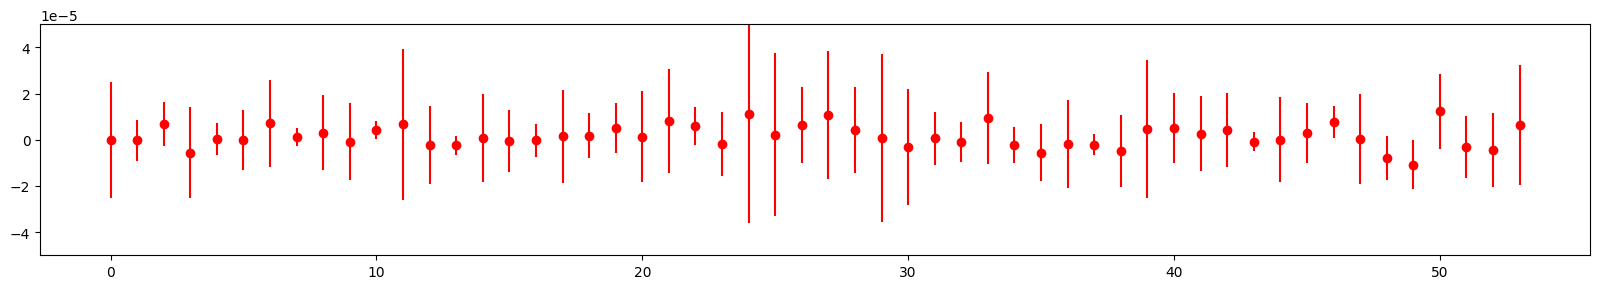

In [6]:
# Compute envelope

envelope = dht.abs()

# Estimate amplitude

endpoint = 16
estimate = envelope[:, +endpoint:-endpoint].mean(1)
spread = envelope[:, +endpoint:-endpoint].std(1)

# Compare

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (estimate - amplitude).cpu().numpy(), yerr=spread.cpu().numpy(), fmt=' ', marker='o', color='red')
plt.ylim(-5.0E-5, +5.0E-5)
plt.show()

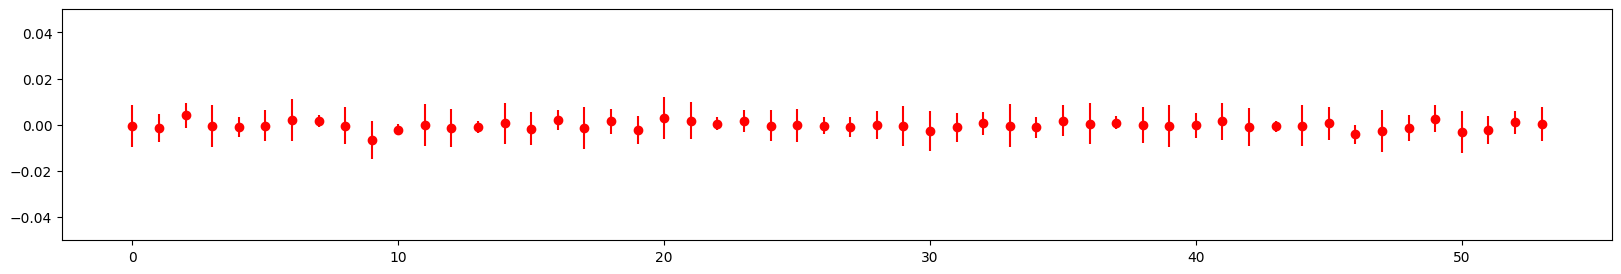

In [7]:
# Estimate phase

angle = dht.angle()
endpoint = 16
angle -= 2.0*numpy.pi*frequency*torch.linspace(0, length - 1, length, dtype=dtype, device=device)
angle = mod(angle, 2.0*numpy.pi, -numpy.pi)
estimate = angle[:, +endpoint:-endpoint].mean(1)
spread = angle[:, +endpoint:-endpoint].std(1)

# Compare

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (estimate - phase).cpu().numpy(), yerr=spread.cpu().numpy(), fmt=' ', marker='o', color='red')
plt.ylim(-5.0E-2, +5.0E-2)
plt.show()